In [ ]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import SRToolkit.utils as utils
from SRToolkit.evaluation import SR_evaluator
from SRToolkit.utils.symbol_library import SymbolLibrary
from SRToolkit.utils.grammar import Grammar
random.seed(123)


In [312]:
class MCTSNode:
    def __init__(self, state, parent=None, applied_rule=None, depth=0):
        self.state = list(state)
        self.parent = parent
        self.applied_rule = applied_rule
        self.depth = depth
        self.children = []
        self.visits = 0
        self.value = 0.0

    def best_child(self, c_param=1.4, use_puct=True):
        log_parent = np.log(self.visits) if self.visits > 0 else 0.0

        def uct(child):
            if child.visits == 0:
                return float('inf')
            exploitation = child.value / child.visits
            exploration = c_param * np.sqrt(log_parent / child.visits)
            return exploitation + exploration
        
        def puct(child):
            parent_visits = max(1, self.visits)
            q = 0.0 if child.visits == 0 else child.value / child.visits
            prior = child.applied_rule.weight
            exploration = c_param * prior * np.sqrt(parent_visits) / (1 + child.visits)
            return q + exploration
        
        if use_puct:
            return max(self.children, key=puct)
        else:
            return max(self.children, key=uct)


class mcts:
    def __init__(self, grammar, reward, max_rollout_depth=100, c_param=1.4, use_puct=True):
        self.grammar = grammar
        self.max_depth = max_rollout_depth
        self.reward = reward
        self.c_param = c_param
        self.rollout_results = []
        self.use_puct = use_puct

    def get_leftmost_nt(self, state):
        for idx, symbol in enumerate(state):
            if symbol in self.grammar.nonterminals:
                return idx, symbol
        return None, None

    def is_terminal(self, state):
        idx, _ = self.get_leftmost_nt(state)
        return idx is None

    def search(self, iterations):
        self.rollout_results = []
        root = MCTSNode([str(self.grammar.start)])
        for i in range(iterations):
            node = self.tree_policy(root)
            reward = self.simulate(node)
            self.backpropagate(node, reward)
    
        return self.rollout_results


    def tree_policy(self, node):
        #TODO morda dodati epsilon greedy strategijo 
        while not self.is_terminal(node.state):
            idx, nt = self.get_leftmost_nt(node.state)
            applicable = self.grammar.rules_for(nt)

            if len(node.children) < len(applicable):
                return self.expand(node,applicable,idx)
            
            node = node.best_child(c_param=self.c_param, use_puct=self.use_puct)
        return node
    
    def expand(self, node, applicable, index):
        tried = [c.applied_rule for c in node.children]
        untried = [prod for prod in applicable if prod not in tried]

        weights = [prod.weight for prod in untried]
        prod = random.choices(untried, weights=weights, k=1)[0]

        new_state = list(node.state)
        new_state[index:index+1] = list(prod.rhs)

        new_node = MCTSNode(new_state, parent=node, applied_rule=prod, depth=node.depth + 1)
        node.children.append(new_node)
        return new_node
    

    def simulate(self, node):

        current_state = list(node.state)
        depth = node.depth

        while not self.is_terminal(current_state) and depth < self.max_depth:
  
            idx, nt = self.get_leftmost_nt(current_state)
            rules = self.grammar.rules_for(nt)
            probs = [r.weight for r in rules]
            selected = random.choices(rules, weights=probs, k=1)[0]
            current_state[idx:idx+1] = list(selected.rhs)
            depth += 1
        

        if not self.is_terminal(current_state):
            print("warning: reached max depth without terminal state")
            return 0.0

        state_string = "".join(str(t) for t in current_state)
        reward = self.reward(state_string)
        self.rollout_results.append((state_string, reward))
        return reward

    def backpropagate(self, node, reward):
        while node is not None:
            node.visits += 1
            node.value += reward
            node = node.parent


In [7]:
def mc_search(grammar, iterations, utility):
    results = []
    for i in range(iterations):
        state = grammar.generate_one()
        reward = utility(state)
        state_string = "".join(str(t) for t in state)
        results.append((state_string, reward))
    return results

In [313]:
# za zacetek vzamemo 3

p_a = 0.1
p_b = 0.9
p_c = 0.9

grammar_str = f"""
    E -> A B C [1.0]
    
    A -> A 'a' [{p_a}]
    A -> 'a'   [{1 - p_a}]
    
    B -> B 'b' [{p_b}]
    B -> 'b'   [{1 - p_b}]
    
    C -> C 'c' [{p_c}]
    C -> 'c'   [{1 - p_c}]
"""

def gini_impurity(expr):
    return 1 - sum(expr.count(c)**2 for c in set(expr))/len(expr)**2

grammar = Grammar.from_grammar_string(grammar_str, start="E")
tree_search_puct = mcts(grammar, reward=gini_impurity, max_rollout_depth=100)
results_mcts_puct = tree_search_puct.search(1000)
results_mc = mc_search(grammar, 1000, gini_impurity)
results_mcts_puct
tree_search_uct = mcts(grammar, reward=gini_impurity, max_rollout_depth=100, use_puct=False)
results_mcts_uct = tree_search_uct.search(1000)


Izračunamo še  ``` drseče povprečje ```, da vidimo, koliko se model sploh uči.

In [9]:
def plot_progress(results, name, window = 20):

    scores = [item[1] for item in results]
    max_scores = np.maximum.accumulate(scores)

    moving_avg = np.convolve(scores, np.ones(window)/window, mode='valid')
    moving_median = pd.Series(scores).rolling(window=window).median().dropna().to_numpy()

    plt.figure(figsize=(10, 5))
    
    plt.scatter(range(len(scores)), scores, color='black', alpha=0.5, s=5, label='nagradna funkcija iteracije')
    plt.plot(range(len(max_scores)), max_scores, color='blue', linewidth=2, label='nagradna funkcija najboljšega rezultata')
    # plt.plot(range(window-1, len(scores)), moving_avg, color='red', label='moving average')
    plt.plot(range(window-1, len(scores)), moving_median, color='green', label='moving median')
    plt.title(name)
    # plt.ylim(0.0, 1.0)
    # plt.xlim(0, len(scores))
    plt.xlabel('Število iteracij')
    plt.ylabel('Funkcija nagrade')
    plt.legend()
    
    plt.show()


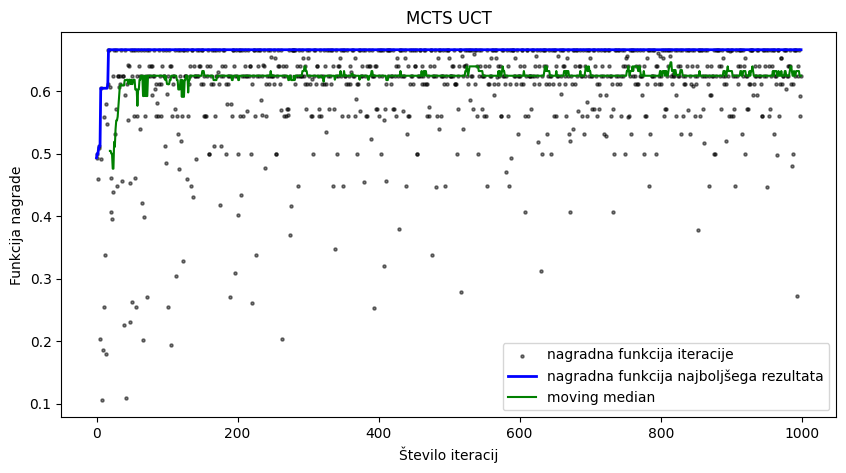

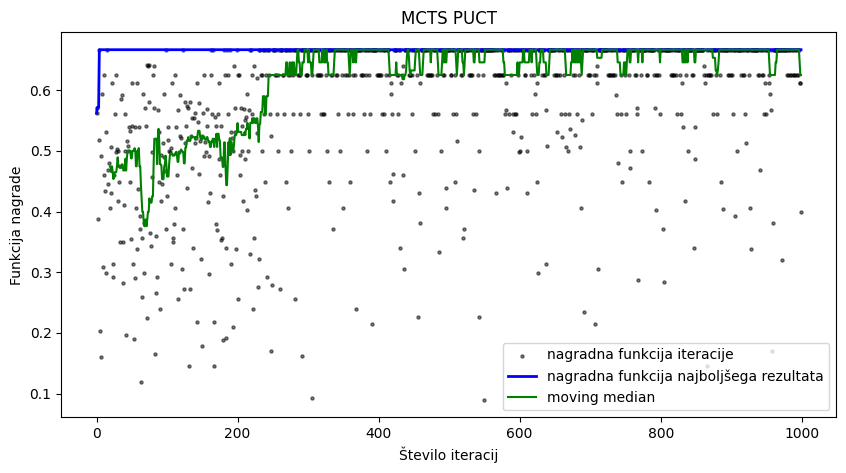

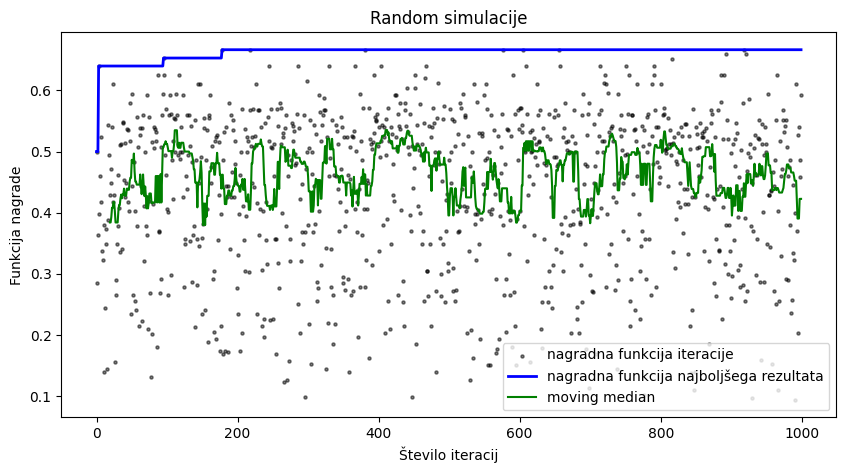

In [314]:
plot_progress(results_mcts_uct, name="MCTS UCT")
plot_progress(results_mcts_puct, name="MCTS PUCT")
plot_progress(results_mc, name="Random simulacije")

Poizkus implementacije za enačbe:

In [210]:
from SRToolkit.utils.grammar import MaxNodes, MaxDepth

In [ ]:
class MCTSNode:
    def __init__(self, state, parent=None, applied_rule=None, depth=0):
        self.state = list(state)
        self.parent = parent
        self.applied_rule = applied_rule
        self.depth = depth
        self.children = []
        self.visits = 0
        self.value = 0.0
        self.rule_path = []
        if parent is not None and applied_rule is not None:
            self.rule_path = parent.rule_path + [applied_rule]
        if parent and applied_rule:
            self.log_prob = parent.log_prob + np.log(applied_rule.weight)
        else:
            self.log_prob = 0.0

    def best_child(self, c_param=1.4, use_puct=True):
        log_parent = np.log(self.visits) if self.visits > 0 else 0.0

        def uct(child):
            if child.visits == 0:
                return float('inf')
            exploitation = child.value / child.visits
            exploration = c_param * np.sqrt(log_parent / child.visits)
            return exploitation + exploration
        
        def puct(child):
            parent_visits = max(1, self.visits)
            q = 0.0 if child.visits == 0 else child.value / child.visits
            prior = child.applied_rule.weight
            exploration = c_param * prior * np.sqrt(parent_visits) / (1 + child.visits)
            return q + exploration
        
        if use_puct:
            return max(self.children, key=puct)
        else:
            return max(self.children, key=uct)


class GRAMS:
    def __init__(self, grammar, reward, evaluator, error = 1e-7, max_rollout_depth=100, c_param=1.4, use_puct=True):
        self.grammar = grammar
        self.reward = reward
        self.evaluator = evaluator
        self.error = error
        self.max_depth = max_rollout_depth
        self.best_model = None
        self.min_rmse = float('inf')
        self.history = []
        self.n_points = self.evaluator.X.shape[0]
        self.c_param = c_param
        self.use_puct = use_puct

        # check if grammar is valid PCFG
        EPSILON = 1e-6
        probs = {}
        for rule in self.grammar.to_dict()["rules"]:
            lhs = rule["lhs"]
            probs[lhs] = probs.get(lhs, 0) + rule["weight"]

        for lhs, total_p in probs.items():
            if not ((1.0 - EPSILON) < total_p < (1.0 + EPSILON)):
                raise ValueError(f"Productions for {lhs} do not sum to 1")
            
        self.grammar.add_constraint(MaxNodes(10))
        self.grammar.add_constraint(MaxDepth(max_rollout_depth))

    def _replay_derivation(self, rule_path):
        d = self.grammar.start_derivation(str(self.grammar.start))
        for rule in rule_path:
            d.apply(rule)
        return d

    def get_leftmost_nt(self, state):
        for idx, symbol in enumerate(state):
            if symbol in self.grammar.nonterminals:
                return idx, symbol
        return None, None

    def is_terminal(self, state):
        idx, _ = self.get_leftmost_nt(state)
        return idx is None
    
    def search(self, iterations):
        self.history = []
        self.min_rmse = float('inf')
        self.best_model = None
        
        root = MCTSNode([str(self.grammar.start)])
        for i in range(iterations):
            node = self.tree_policy(root)
            reward = self.simulate(node)
            self.backpropagate(node, reward)
            if self.min_rmse <= self.error:
                print(f"Stopping early at iteration {i} with RMSE {self.min_rmse}")
                return self.evaluator.get_results(top_k=1)
        if not self.evaluator.models:
            return self.evaluator.get_results(top_k=0)
        results =self.evaluator.get_results(top_k=1)
        if len(results) == 0 or len(results[0].top_models) == 0:
            print("Warning: No valid models found during search.")
            return results
        return results

    def tree_policy(self, node):
        while not self.is_terminal(node.state):
            index, nt = self.get_leftmost_nt(node.state)
            applicable = self.grammar.rules_for(nt)

            if len(node.children) < len(applicable):
                return self.expand(node,applicable,index)
            
            node = node.best_child(c_param=self.c_param, use_puct=self.use_puct)
        return node
    
    def expand(self, node, applicable, index):
        tried = [c.applied_rule for c in node.children]
        untried = [prod for prod in applicable if prod not in tried]

        weights = [prod.weight for prod in untried]
        prod = random.choices(untried, weights=weights, k=1)[0]

        new_state = list(node.state)
        new_state[index:index+1] = list(prod.rhs)

        new_node = MCTSNode(new_state, parent=node, applied_rule=prod, depth=node.depth + 1)
        node.children.append(new_node)
        return new_node
    
    
    def simulate(self, node):
        derivation = self._replay_derivation(node.rule_path)
        rollout_log_prob = node.log_prob

        while not derivation.complete:
            surviving_rules = derivation.options()

            if not surviving_rules:
                return 0.0

            weights = [float(r.weight) for r in surviving_rules]
            total = sum(weights)
            probs = [w / total for w in weights] if total > 0 else [1.0 / len(surviving_rules)] * len(surviving_rules)

            choice_idx = np.random.choice(len(surviving_rules), p=probs)
            selected_rule = surviving_rules[choice_idx]
            rollout_log_prob += np.log(max(probs[choice_idx], 1e-12))

            derivation.apply(selected_rule)

            if derivation.complete:
                break

        tokens = [str(t).strip("'\"") for t in derivation.to_token_list()]
        state_str = "".join(tokens)

        rmse = self.evaluator.evaluate_expr(tokens)

        if np.isnan(rmse) or np.isinf(rmse):
            return 0.0

        if state_str not in self.evaluator.models:
            return 0.0

        model_res = self.evaluator.models[state_str]
        num_params = len(getattr(model_res, 'parameters', []))

        current_reward = self.reward(
            rmse=rmse,
            k=num_params + 1,
            n=self.n_points,
            log_prob=rollout_log_prob
        )

        if rmse < self.min_rmse:
            self.min_rmse = rmse
            self.best_model = state_str

        self.history.append((state_str, rmse, current_reward))
        return current_reward

    def backpropagate(self, node, reward):
        while node is not None:
            node.visits += 1
            node.value += reward
            node = node.parent

    def standard_mc(self, node, iterations):
        total_reward = 0.0
        for _ in range(iterations):
            reward = self.simulate(node)
            total_reward += reward
        return total_reward / iterations


In [259]:
# TODO: 
# enotna funkcija za testiranje
# enotna funkcija grams

def test_mcts(variables, X, y, reward, grammar_str, start_symbol, iterations=1000, max_rollout_depth=100):
    grammar = Grammar.from_grammar_string(grammar_str, start=start_symbol)
    lib = SymbolLibrary.default_symbols(num_variables=len(variables))
    eval = SR_evaluator(X=X, y=y, symbol_library=lib)
    mcts = GRAMS(grammar=grammar, reward=reward, evaluator=eval, error=1e-9, max_rollout_depth=max_rollout_depth)
    # results, best_model, best_rmse = mcts.search(iterations)
    results = mcts.search(iterations)
    if results and len(results) > 0 and len(results[0].top_models) > 0:
        print(f"Best model: {results[0].best_expr} with RMSE: {results[0].min_error}")
        return results, mcts.history
    else:
        print("No valid models found during search.")
        return results, mcts.history

In [288]:
variables = ["X_0", "X_1"]
grammar = "E -> E '+' F [0.2] | E '-' F [0.2] | F [0.6]\n"
grammar += "F -> F '*' T [0.2] | F '/' T [0.2] | T [0.6]\n"
grammar += "T -> '(' E ')' [0.2] | V [0.6] | 'sin' '(' E ')' [0.2]\n"
grammar += "\n".join([f"V -> '{v}' [{1/len(variables)}]" for v in variables])

N = 100
x_train = np.random.uniform(-5, 5, (N, len(variables)))
y_train = x_train[:, 1] / x_train[:, 0]

# preprosta funkcija nagrade za testiranje (samo z napako RMSE)
def reward_rmse(*, rmse, **kwargs):
    return 1/(rmse + 1e-6)

results, history = test_mcts(variables, x_train, y_train, reward_rmse, grammar, 'E', iterations=1000,  max_rollout_depth=15)

Stopping early at iteration 67 with RMSE 0.0
Best model: (X_1)/X_0 with RMSE: 0.0


In [ ]:
variables = ["X_0", "X_1", "X_2"]
grammar_str = "E -> E '+' T [0.4] | T [0.6]\n"
grammar_str += "T -> 'C' '*' V [0.7] | V [0.3]\n"
grammar_str += "\n".join([f"V -> '{v}' [{1/len(variables)}]" for v in variables])

N = 100
x_train = np.random.uniform(-5, 5, (N, len(variables)))
y_train = 2.5 * x_train[:, 0] -2 * x_train[:, 1] + 4 * x_train[:, 2]

results, history = test_mcts(variables, x_train, y_train, reward_rmse, grammar_str, 'E', iterations=1000,  max_rollout_depth=10000)

Best model: C*X_1+C*X_2+C*X_0 with RMSE: 1.22111286625856e-06


In [282]:
variables = ["X_0", "X_1", "X_2", "X_3"]
grammar = "E -> E '+' F [0.2] | E '-' F [0.2] | F [0.6]\n"
grammar += "F -> F '*' T [0.2] | F '/' T [0.2] | T [0.6]\n"
grammar += "T -> '(' E ')' [0.2] | V [0.6] | 'sin' '(' E ')' [0.2]\n"
grammar += "\n".join([f"V -> '{v}' [{1/len(variables)}]" for v in variables])

N = 1000
x_train = np.random.uniform(-5, 5, (N, len(variables)))
y_train = x_train[:, 0] - 3*x_train[:, 1] - x_train[:, 2] - x_train[:, 3]

results, history = test_mcts(variables, x_train, y_train, reward_rmse, grammar, 'E', iterations=1000,  max_rollout_depth=1000)

Best model: X_0-X_1 with RMSE: 7.297072135863088


In [241]:
def reward_new(rmse, k,n,log_prob):
    log_posterior = - k/2 * np.log(n) + log_prob - n/2*np.log(2*np.pi) -n/2 - n*np.log(rmse)
    return 1/(1+abs(log_posterior))

In [299]:
variables = ["X_0", "X_1", "X_2", "X_3"]
grammar = "E -> E '+' F [0.2] | E '-' F [0.2] | F [0.6]\n"
grammar += "F -> F '*' T [0.2] | F '/' T [0.2] | T [0.6]\n"
grammar += "T -> '(' E ')' [0.2] | V [0.6] | 'sin' '(' E ')' [0.2]\n"
grammar += "\n".join([f"V -> '{v}' [{1/len(variables)}]" for v in variables])

N = 1000
x_train = np.random.uniform(-5, 5, (N, len(variables)))
y_train = x_train[:, 0] - 3*x_train[:, 1] - x_train[:, 2] - x_train[:, 3]

results, history = test_mcts(variables, x_train, y_train, reward_new, grammar, 'E', iterations=2000,  max_rollout_depth=1000)


Best model: X_0-X_1 with RMSE: 6.995721733022128


In [310]:
def plot_progress_rmse(results, name, window=20):

    rmses = np.array([item[1] for item in results], dtype=float)
    best_rmse = np.minimum.accumulate(rmses)

    # moving_avg = np.convolve(rmses, np.ones(window)/window, mode='valid')
    
    plt.figure(figsize=(10, 5))
    moving_median = pd.Series(rmses).rolling(window=window).median().dropna().to_numpy()

    plt.scatter(range(len(rmses)), rmses, color='black', alpha=0.5, s=5, label='RMSE v iteraciji')
    plt.plot(range(len(best_rmse)), best_rmse, color='blue', linewidth=2, label='najmanjši RMSE do zdaj')
    # plt.plot(range(window-1, len(rmses)), moving_avg, color='red', label=f'moving average')
    plt.plot(range(window-1, len(rmses)), moving_median, color='green', label='moving median')
    plt.title(name)
    plt.xlabel('Število iteracij')
    plt.ylabel('RMSE')
    plt.legend()

    plt.show()


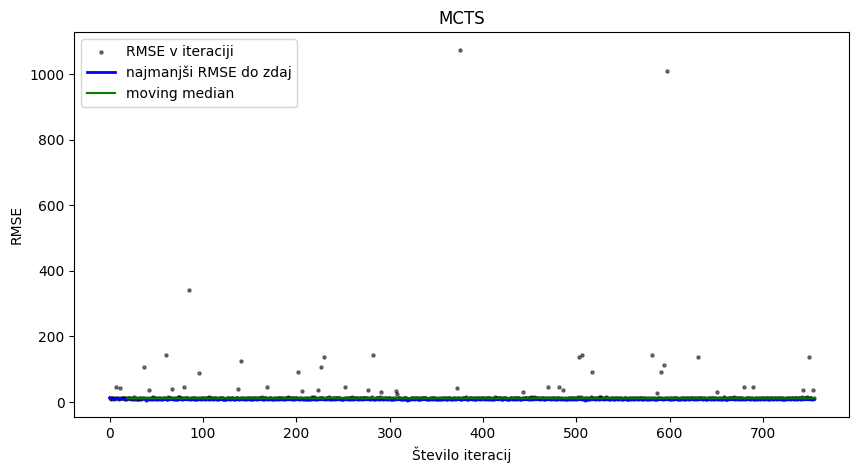

In [311]:
plot_progress_rmse(history, name="MCTS")